# U3: Aprendizaje no supervizado: Clustering
## FCEIA | Tec. Universitaria en Inteligencia Artificial | Minería de Datos

# 1. Repaso: ¿Qué es Clustering?
En clase discutimos la diferencia fundamental entre dos grandes paradigmas del Machine Learning:

* **Aprendizaje Supervisado:** Entrenamos modelos para predecir una etiqueta conocida (ej. predecir el precio de una casa o clasificar un correo como spam).
* **Aprendizaje No Supervisado:** Trabajamos con datos **sin etiquetar**. Nuestro objetivo es descubrir la estructura oculta, los patrones o las relaciones en los datos.

El **Clustering** (o agrupamiento) es una de las técnicas del *aprendizaje no supervisado*. Su objetivo es dividir un conjunto de datos en grupos (clústeres) de manera que se cumplan dos reglas principales:
1. **Alta cohesión:** Los elementos dentro del mismo clúster deben ser lo más similares posible entre sí.
2. **Alta separación:** Los elementos de clústeres diferentes deben ser lo más distintos posible.

## 🎯 Caso de estudio: Semillas de Trigo
Hoy trabajaremos con un conjunto de datos que contiene mediciones geométricas de granos de trigo (área, perímetro, asimetría, longitud del surco, etc.).
Aunque sabemos que en realidad existen tres variedades de trigo en este dataset (Kama, Rosa y Canadian), **vamos a ocultar esta información (la etiqueta) al algoritmo**. Nuestro objetivo será ver si el algoritmo K-Means es capaz de "descubrir" estas 3 familias por sí solo, basándose únicamente en la similitud de la forma geométrica de los granos.

# Librerías

In [ ]:
# Análisis exploratorio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
sns.set_theme(style="whitegrid")

# Preparación de los datos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Algoritmos de clustering
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import dendrogram, linkage

# Métricas
from sklearn.metrics import silhouette_score,silhouette_samples

# Base de datos: Semillas de Trigo
[Dataset en Kaggle: Wheat Variety Classification](https://www.kaggle.com/datasets/sudhanshu2198/wheat-variety-classification)

El conjunto de datos contiene un total de **210 muestras** de granos de trigo pertenecientes a tres variedades diferentes: **Kama, Rosa y Canadian** (70 registros de cada una). Todas las variables registradas corresponden a datos numéricos continuos.

## Información de las variables
Para construir el dataset, se midieron siete características geométricas de los granos de trigo mediante técnicas de análisis de imagen:

- **Área ($A$):** Superficie del grano.
- **Perímetro ($P$):** Longitud del contorno del grano.
- **Compacidad ($C$):** Medida de redondez, calculada como $C = \frac{4\pi A}{P^2}$.
- **Longitud del grano:** Dimensión mayor del grano.
- **Ancho del grano:** Dimensión menor del grano.
- **Coeficiente de asimetría:** Medida de la falta de simetría de la forma.
- **Longitud del surco del grano:** Medida del canal o hendidura central.

In [ ]:
!gdown 1J8I0tGdrTHXjGFM51pxMvO_kBJoIeOm1

Downloading...
From: https://drive.google.com/uc?id=1J8I0tGdrTHXjGFM51pxMvO_kBJoIeOm1
To: /content/wheat.csv
100% 10.0k/10.0k [00:00<00:00, 21.7MB/s]


In [ ]:
df = pd.read_csv("wheat.csv")

# Estructura

In [ ]:
df.head()

,area,perimeter,compactness,length,width,asymmetry coefficient,groove length,category
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1.0
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1.0
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1.0
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1.0
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1.0


In [ ]:
# Chequeamos cantidad de datos, tipos y si hay nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   area                   210 non-null    float64
 1   perimeter              210 non-null    float64
 2   compactness            210 non-null    float64
 3   length                 210 non-null    float64
 4   width                  210 non-null    float64
 5   asymmetry coefficient  210 non-null    float64
 6   groove length          210 non-null    float64
 7   category               210 non-null    float64
dtypes: float64(8)
memory usage: 13.3 KB


In [ ]:
target_names = {
1:'Kama',
2:'Rosa',
3:'Canadian'
}

df['category'] = df['category'].map(target_names).astype('category')
df["category"].value_counts()

,count
category,
Canadian,70
Kama,70
Rosa,70


In [ ]:
df.describe()

,area,perimeter,compactness,length,width,asymmetry coefficient,groove length
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000


# Conjunto de prueba

In [ ]:
train, test = train_test_split(df, test_size=0.2, stratify=df['category'],
                               random_state=42)

# Análisis exploratorio

In [ ]:
# Mapear variables a español
names_map = {
    'area': 'Área',
    'perimeter': 'Perímetro',
    'compactness': 'Compacidad',
    'length': 'Longitud',
    'width': 'Ancho',
    'asymmetry coefficient': 'Coeficiente de Asimetría',
    'groove length': 'Longitud del Surco',
    'category': 'Etiqueta'
}
df.rename(columns=names_map, inplace=True)

In [ ]:
X = df.drop(columns='Etiqueta')
y = df['Etiqueta']

## Matriz de correlación

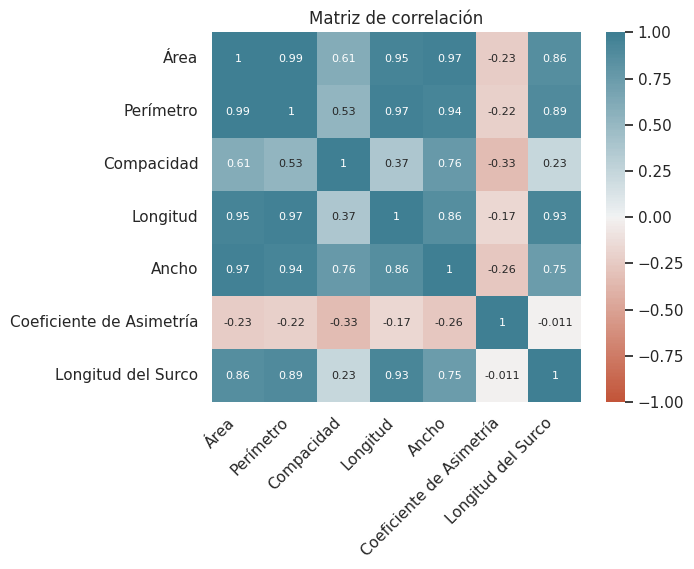

In [ ]:
corr = X.corr()
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot = True,
    annot_kws = {'size': 8}
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
)

plt.title('Matriz de correlación')
plt.show()

## Graficas de distribución



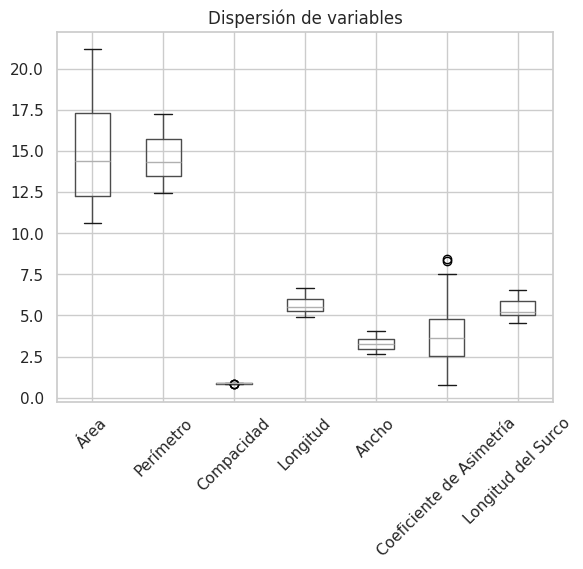

In [ ]:
X.boxplot(rot=45)
plt.title('Dispersión de variables')
plt.show()

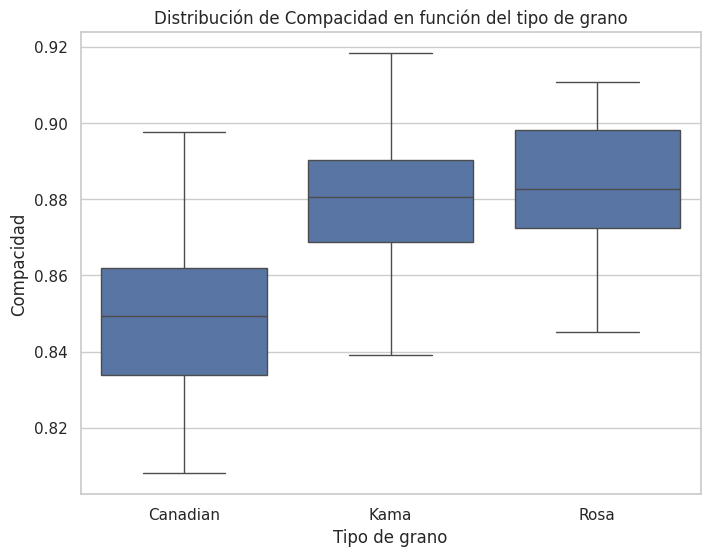

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Etiqueta', y='Compacidad', data=df)
plt.title('Distribución de Compacidad en función del tipo de grano')
plt.xlabel('Tipo de grano')
plt.show()

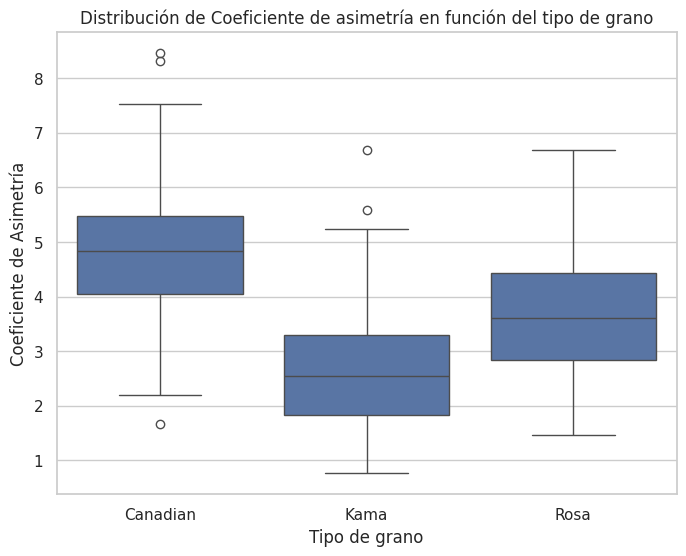

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Etiqueta', y='Coeficiente de Asimetría', data=df)
plt.title('Distribución de Coeficiente de asimetría en función del tipo de grano')
plt.xlabel('Tipo de grano')
plt.show()

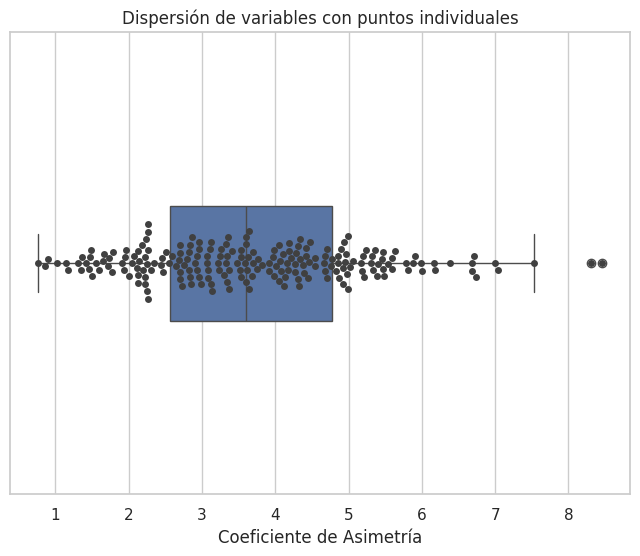

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Coeficiente de Asimetría'], width=0.25)
sns.swarmplot(x=df['Coeficiente de Asimetría'], color='.25')
plt.title('Dispersión de variables con puntos individuales')
plt.xlabel('Coeficiente de Asimetría')
plt.show()

## Gráfica de dispersión

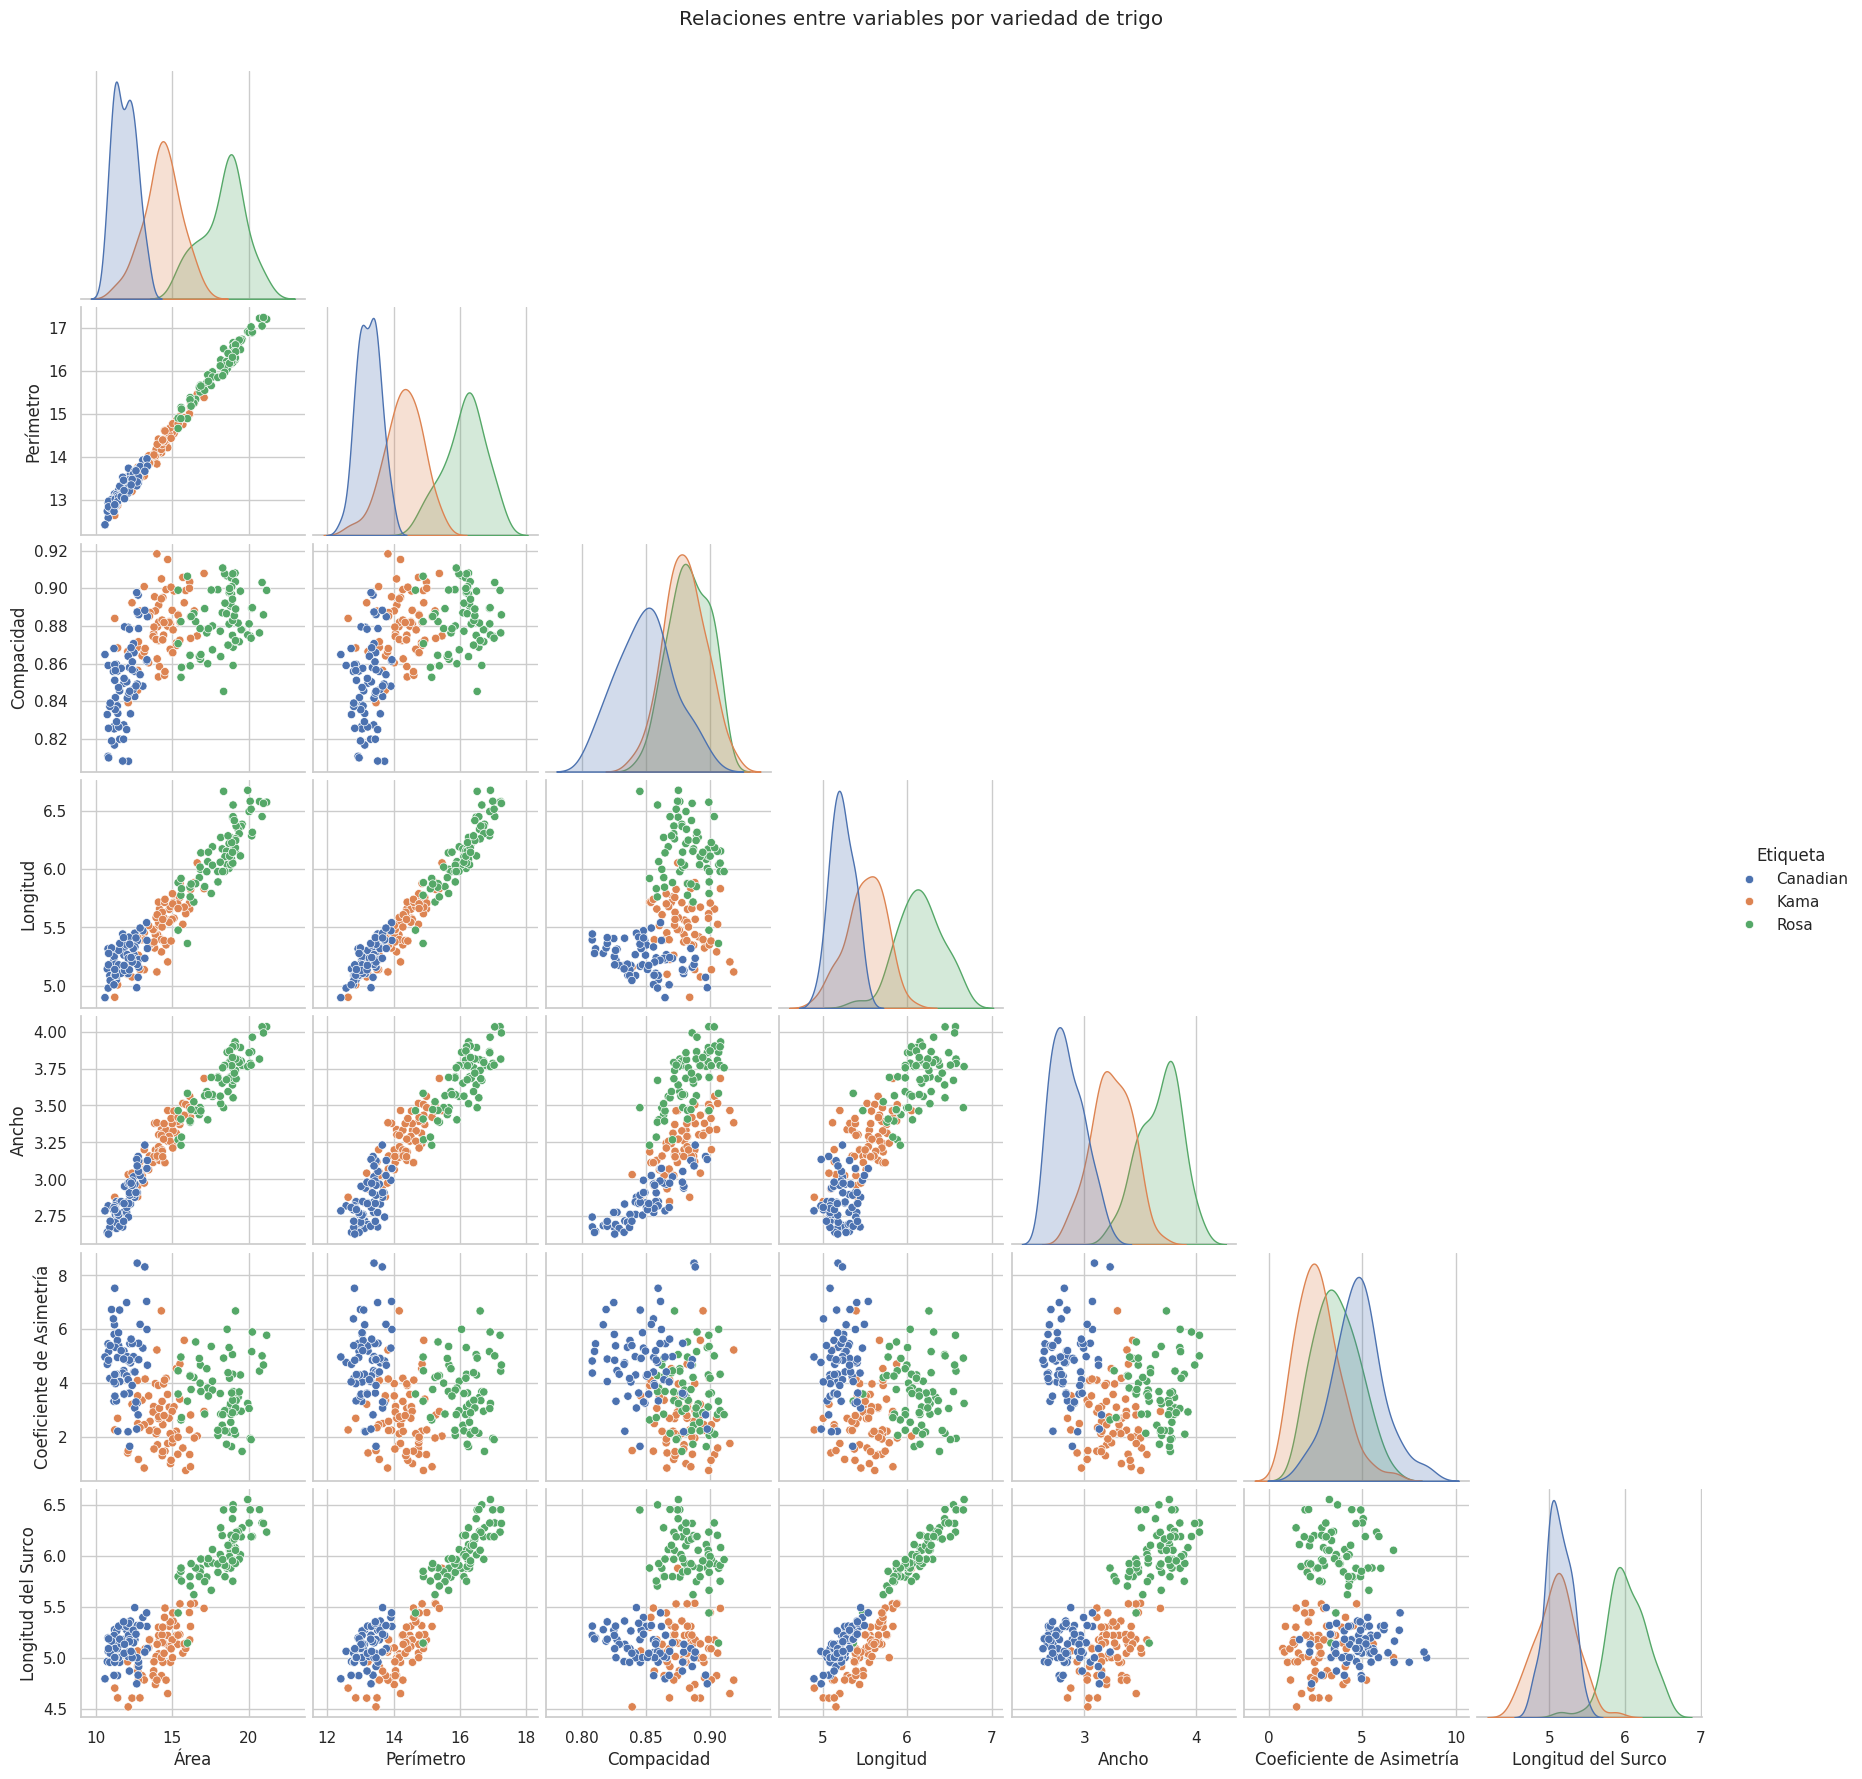

In [ ]:
# Gráfico de pares para observar la separación natural de las clases
sns.pairplot(df, hue='Etiqueta',
             corner=True)
plt.suptitle('Relaciones entre variables por variedad de trigo', y=1.02)
plt.show()

In [ ]:
fig = px.scatter_3d(df, x='Área', y='Longitud', z='Coeficiente de Asimetría',
                    color='Etiqueta',
                    labels=names_map,
                    title='Dispersión de las variedades de trigo')
fig.show()

# Preparación de los datos

## Remocion de Outliers
Luego de verificar que el coeficiente de asimetría por tipo de grano contiene valores atípicos procedemos a removerlos

In [ ]:
def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

out_col = ['Coeficiente de Asimetría']

clean = []

for category_name, group_df in df.groupby('Etiqueta', observed=False):
    clean_group = remove_outliers_iqr(group_df, out_col[0])
    clean.append(clean_group)

clean = pd.concat(clean).reset_index(drop=True)


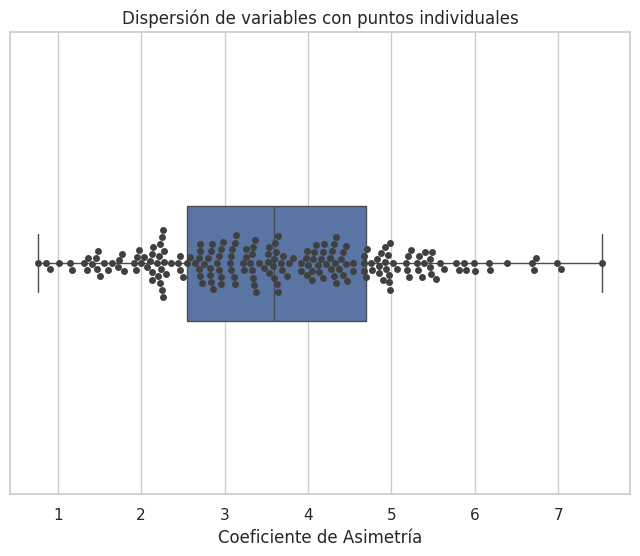

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=clean['Coeficiente de Asimetría'], width=0.25)
sns.swarmplot(x=clean['Coeficiente de Asimetría'], color='.25')
plt.title('Dispersión de variables con puntos individuales')
plt.show()

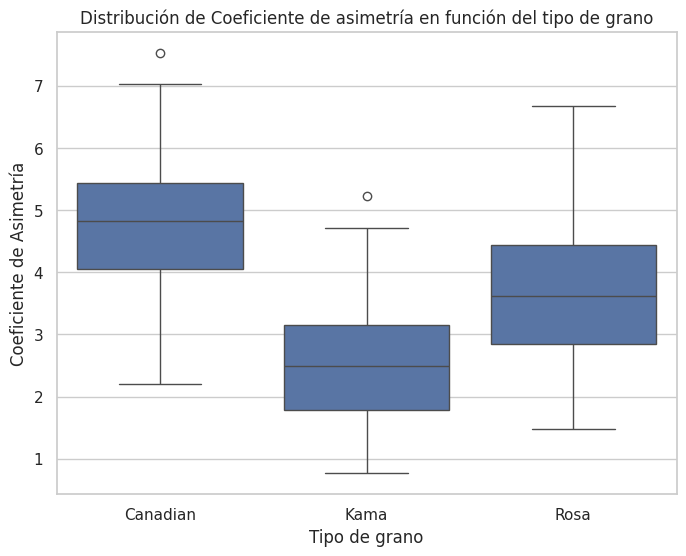

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Etiqueta', y='Coeficiente de Asimetría', data=clean)
plt.title('Distribución de Coeficiente de asimetría en función del tipo de grano')
plt.xlabel('Tipo de grano')
plt.show()

In [ ]:
# Eligo 3 variables para poder visualizar en 3 dimensiones
column_names = ["Área", "Longitud", "Compacidad"]
X_reducido = X[column_names]
X_reducido.head()

,Área,Longitud,Compacidad
0,15.26,5.763,0.8710
1,14.88,5.554,0.8811
2,14.29,5.291,0.9050
3,13.84,5.324,0.8955
4,16.14,5.658,0.9034


## Escalado
Si miramos los rangos de las variables en el análisis estadístico, el `Área` tiene valores cercanos a 15-20, mientras que la `Compacidad` tiene valores alrededor de 0.8.

¿Qué pasaría si calculamos la distancia entre dos muestras usando los datos tal cual están?

Algoritmos como **K-Means** se basan en el cálculo de distancias geométricas (generalmente la Distancia Euclidiana). Por lo tanto, variables con escalas mayores dominarán el cálculo de la distancia. El algoritmo pensaría que el `Área` es mucho más importante que la `Compacidad`, lo cual es un error.

Por lo tanto, un paso **obligatorio** antes de hacer clustering es estandarizar los datos (media 0 y varianza 1) para que todas las variables tengan el mismo peso.

[Documentación de StandardScaler en sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler)

In [ ]:
# Creo el objeto scaler que calcula la media y la desviación estándar de los
# datos y luego aplica la transformación de estandarización.
scaler = StandardScaler().set_output(transform="pandas")
X_std = scaler.fit_transform(X_reducido)
X_std.head()

,Área,Longitud,Compacidad
0,0.142098,0.304218,0.000061
1,0.011188,-0.168625,0.428515
2,-0.192067,-0.763637,1.442383
3,-0.347091,-0.688978,1.039381
4,0.445257,0.066666,1.374509


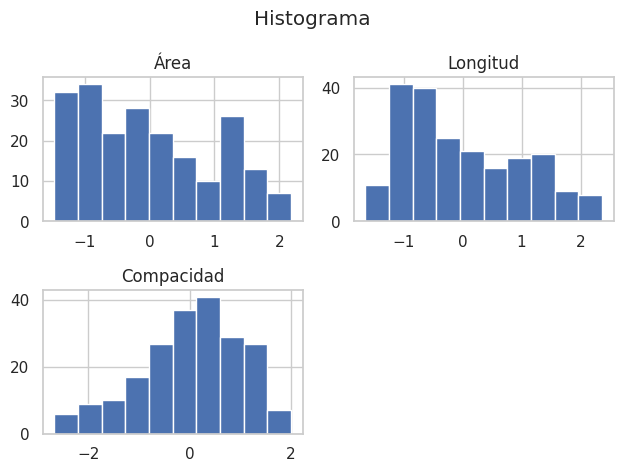

In [ ]:
X_std.hist()
plt.suptitle('Histograma')
plt.tight_layout()
plt.show()

# K means

## Selección de k
El objetivo es identificar un punto en el gráfico donde la disminución en la suma de las distancias intraclúster (también conocida como inercia) comienza a disminuir de manera significativamente más lenta. Este punto se denomina "codo" y sugiere el número adecuado de clústeres para el conjunto de datos.

https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

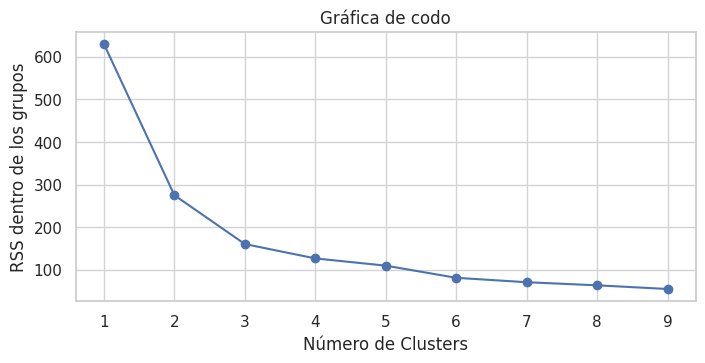

In [ ]:
Nc = range(1, 10)
kmeans = [KMeans(n_clusters=k, random_state=42).fit(X_std) for k in Nc]

# La suma de residuos cuadrados intra grupos de kMeans en sklearn se guarda en
# el atributo inertia
inertias = [model.inertia_ for model in kmeans]

plt.figure(figsize=(8, 3.5))
plt.plot(Nc,inertias, "bo-")
plt.xlabel('Número de Clusters')
plt.ylabel('RSS dentro de los grupos')
plt.title('Gráfica de codo')
plt.grid(color='lightgray')
plt.show()

### Aplicamos el modelo



In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42,
                init='k-means++', n_init=5, algorithm='lloyd')
kmeans.fit(X_std) #Entrenamos el modelo
y_pred = kmeans.predict(X_std)

In [ ]:
np.array_equal(y_pred, kmeans.labels_)

True

In [ ]:
# El metodo labels_ nos da a que cluster corresponde cada observacion
X_std['Etiquetas KMeans'] = kmeans.labels_
X_std['Etiquetas KMeans'] = X_std['Etiquetas KMeans'].astype('category')
X_std.head()

,Área,Longitud,Compacidad,Etiquetas KMeans
0,0.142098,0.304218,0.000061,1
1,0.011188,-0.168625,0.428515,1
2,-0.192067,-0.763637,1.442383,1
3,-0.347091,-0.688978,1.039381,1
4,0.445257,0.066666,1.374509,1


In [ ]:
np.set_printoptions(precision=6)
kmeans.cluster_centers_
# caracteristicas normalizadas que tendria el centroide de ese cluster.

array([[ 1.297732,  1.284194,  0.592632],
       [-0.208811, -0.329492,  0.402323],
       [-1.084951, -0.897534, -1.208804]])

**Desafío**: Verificar si los centroides se corresponden con el valor medio de los grupos creados.

In [ ]:
fig = px.scatter_3d(X_std,
                    x=column_names[0], y=column_names[1], z=column_names[2],
                    color='Etiquetas KMeans',
                    title='Dispersión de las variedades de trigo (K-means)')
fig.show()

In [ ]:
fig = px.scatter_3d(X_std,
                    x=column_names[0], y=column_names[1], z=column_names[2],
                    color=y,
                    title='Dispersión de las variedades de trigo (original)')
fig.show()

**Tarea**: verificar en que puntos no coinciden los clusters de Kmeans con las etiquetas verdaderas.

## Clustering Jerárquico

In [ ]:
# Importa la función linkage de SciPy para realizar el clustering jerárquico
Z = linkage(X_std, "ward")

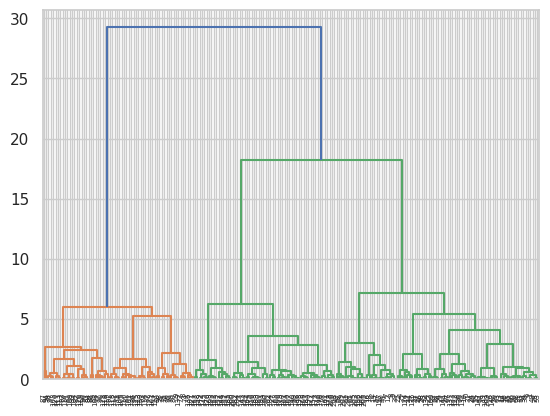

In [ ]:
# Dibuja un dendrograma para visualizar el resultado del clustering jerárquico
dendrogram(Z)
plt.show()

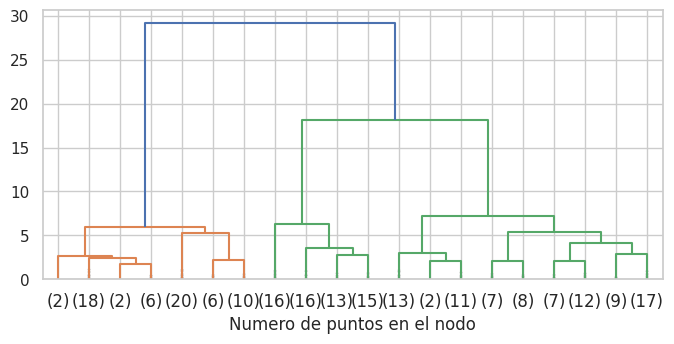

In [ ]:
# Dibuja un dendrograma truncado (solo muestra las últimas p hojas)
plt.figure(figsize=(8, 3.5))
dendrogram(Z,  truncate_mode = 'lastp', p = 20, show_leaf_counts = True,
           show_contracted = True)
plt.axhline(y=110, c='k', linestyle='dashed')
plt.xlabel("Numero de puntos en el nodo")
plt.show()

In [ ]:
from scipy.spatial.distance import cdist

distancias=[]
for i in range(1, 10):
    clustering = AgglomerativeClustering(n_clusters=i) # Aplica clustering jerárquico con i clusters
    clustering.fit(X_std)

    # Calcula la matriz de distancias por pares entre los puntos
    pairwise_distances = cdist(X_std, X_std, 'euclidean')

    # Calcula la distancia total dentro de los clusters
    distancia_total = 0
    for j in range(i):
        cluster_indices = np.where(clustering.labels_ == j)
        # Encuentra los índices de los puntos en el cluster j
        distancia_total += pairwise_distances[cluster_indices][:, cluster_indices].sum()
        # Suma las distancias dentro del cluster


    distancias.append(distancia_total)
    # Almacena la distancia total para el número de clusters i

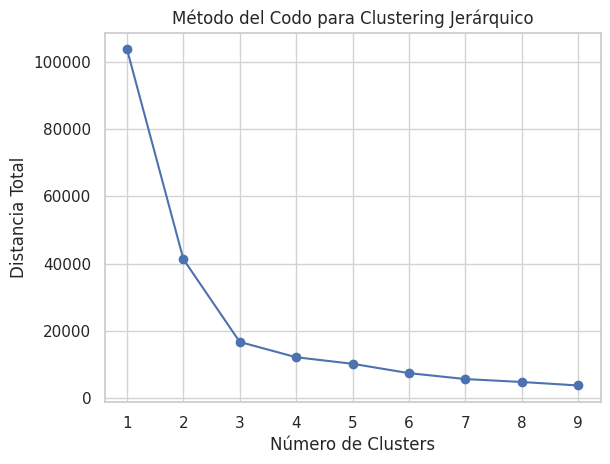

In [ ]:
# Grafica la distancia total en función del número de clusters
plt.plot(range(1, 10), distancias, marker='o')
plt.xlabel('Número de Clusters')
plt.ylabel('Distancia Total')
plt.title('Método del Codo para Clustering Jerárquico')
plt.grid(color='lightgray')
plt.show()

In [ ]:
n_clusters = 3
clustering = AgglomerativeClustering(n_clusters=n_clusters)

cluster_assignments = clustering.fit_predict(X_std)
# Asigna los clusters a los datos

X_std['Etiquetas jerarquico'] = cluster_assignments
# Añade la columna con el cluster asignado a cada punto

X_std.head()

,Área,Longitud,Compacidad,Etiquetas KMeans,Etiquetas jerarquico
0,0.142098,0.304218,0.000061,1,0
1,0.011188,-0.168625,0.428515,1,0
2,-0.192067,-0.763637,1.442383,1,0
3,-0.347091,-0.688978,1.039381,1,0
4,0.445257,0.066666,1.374509,1,0


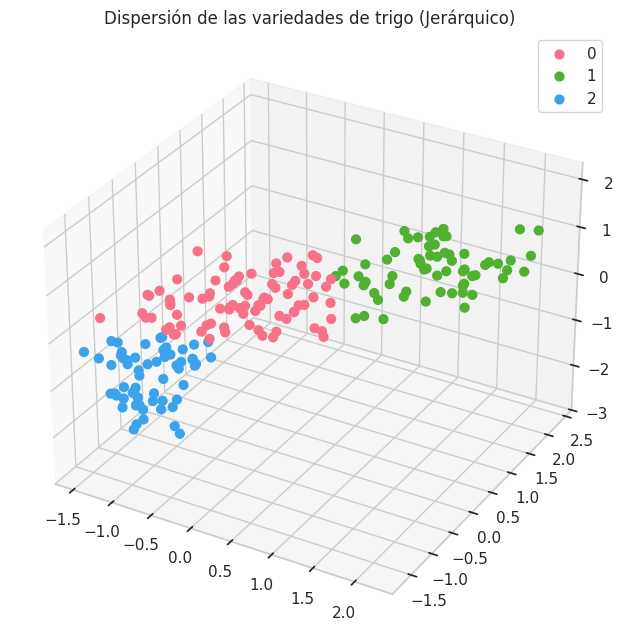

In [ ]:
fig = plt.figure(figsize=(10, 6))
ax = Axes3D(fig, auto_add_to_figure=False)
fig.add_axes(ax)
labels = np.unique(X_std['Etiquetas jerarquico'])
palette = sns.color_palette("husl", len(labels))
for label, color in zip(labels, palette):
  df1 = X_std[X_std['Etiquetas jerarquico'] == label]
  ax.scatter(df1[column_names[0]], df1[column_names[1]], df1[column_names[2]],
             s=40, marker='o', color=color, alpha=1, label=label)

ax.legend(loc='best')
plt.title('Dispersión de las variedades de trigo (Jerárquico)')
plt.show()

In [ ]:
# Calcula el coeficiente de Silhouette promedio
silhouette_score(X_std, cluster_assignments)

np.float64(0.60111176237241)

## DBSCAN y HDBSCAN

In [ ]:
!pip install hdbscan

In [ ]:
from sklearn.cluster import DBSCAN
from hdbscan import HDBSCAN

### Parámetros DBSCAN (Density-Based Spatial Clustering of Applications with Noise):

`eps (Epsilon)`: Este parámetro controla la distancia máxima entre dos muestras para que una sea considerada parte del mismo clúster. En otras palabras, establece la distancia máxima entre puntos vecinos que se agruparán juntos. Un valor pequeño de eps puede hacer que el algoritmo encuentre más clústeres, mientras que un valor grande puede fusionar más puntos en un solo clúster.

`min_sample`s: Este parámetro define el número mínimo de muestras (puntos de datos) en un vecindario para que un punto sea considerado núcleo (core point). Los puntos núcleo son aquellos que tienen al menos `min_samples` puntos dentro de una distancia de `eps`. Los puntos que no son núcleo, pero están dentro del vecindario de un punto núcleo, se consideran puntos límite o de borde.



In [ ]:
# Aplico DBSCAN con parámetros eps y min_samples
dbscan = DBSCAN(eps=0.6, min_samples=12)
dbscan_labels = dbscan.fit_predict(X_std)


# Cuenta el número de clusters identificados, excluyendo el ruido (-1)
groups = len(set(dbscan_labels))
count_noise = (1 if -1 in dbscan_labels else 0)

print("Número de clústeres identificados por DBSCAN:", groups - count_noise)

Número de clústeres identificados por DBSCAN: 3


In [ ]:
count_noise

1

### HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise):

`min_cluster_size`: Este parámetro establece el tamaño mínimo del clúster. Los clústeres con menos puntos no se considerarán como clústeres válidos y se etiquetarán como ruido (-1 en las etiquetas). Aumentar este valor tiende a producir menos clústeres.

In [ ]:
# Aplica HDBSCAN con parámetro min_cluster_size

hdbscan = HDBSCAN(min_cluster_size=5)
hdbscan_labels = hdbscan.fit_predict(X_std)

# Cuenta el número de clusters identificados, excluyendo el ruido (-1)
groups = len(set(hdbscan_labels))
count_noise = (1 if -1 in hdbscan_labels else 0)

print("Número de clústeres identificados por HDBSCAN:", groups - count_noise)

Número de clústeres identificados por HDBSCAN: 3


In [ ]:
count_noise

0

In [ ]:
X_std['Cluster DBSCAN'] = dbscan_labels
X_std['Cluster HDBSCAN'] = hdbscan_labels

In [ ]:
X_std

,Área,Longitud,Compacidad,Etiquetas KMeans,Etiquetas jerarquico,Cluster DBSCAN,Cluster HDBSCAN
0,0.142098,0.304218,0.000061,1,0,0,2
1,0.011188,-0.168625,0.428515,1,0,0,2
2,-0.192067,-0.763637,1.442383,1,0,0,2
3,-0.347091,-0.688978,1.039381,1,0,0,2
4,0.445257,0.066666,1.374509,1,0,0,2
...,...,...,...,...,...,...,...
205,-0.915515,-1.112048,0.309736,1,0,0,2
206,-1.246235,-1.105261,-0.844122,2,2,1,0
207,-0.567571,-0.888070,0.733948,1,0,0,2
208,-1.036090,-1.026077,-0.801701,2,2,1,0


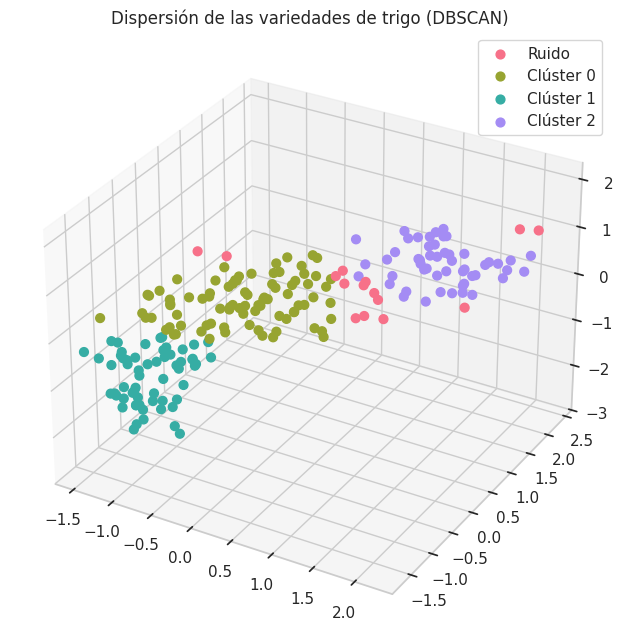

In [ ]:
# Grafico los clusters obtenidos por DBSCAN
fig = plt.figure(figsize=(10, 6))
ax = Axes3D(fig, auto_add_to_figure=False)
fig.add_axes(ax)

# Obtengo los valores únicos de los clústeres (incluyendo el ruido, que es -1)
labels = np.unique(X_std['Cluster DBSCAN'])

# Creo una paleta de colores
palette = sns.color_palette("husl", len(labels))

# Recorro los clústeres y asigno un color a cada uno
for label, color in zip(labels, palette):
    df1 = X_std[X_std['Cluster DBSCAN'] == label]

    # Defino la etiqueta para el ruido
    if label == -1:
        cluster_label = 'Ruido'
    else:
        cluster_label = f'Clúster {label}'

    # Grafico los puntos para cada clúster
    ax.scatter(df1[column_names[0]], df1[column_names[1]], df1[column_names[2]],
               s=40, marker='o', color=color, alpha=1, label=cluster_label)

# Muestra la leyenda
ax.legend(loc='best')
plt.title('Dispersión de las variedades de trigo (DBSCAN)')
plt.show()

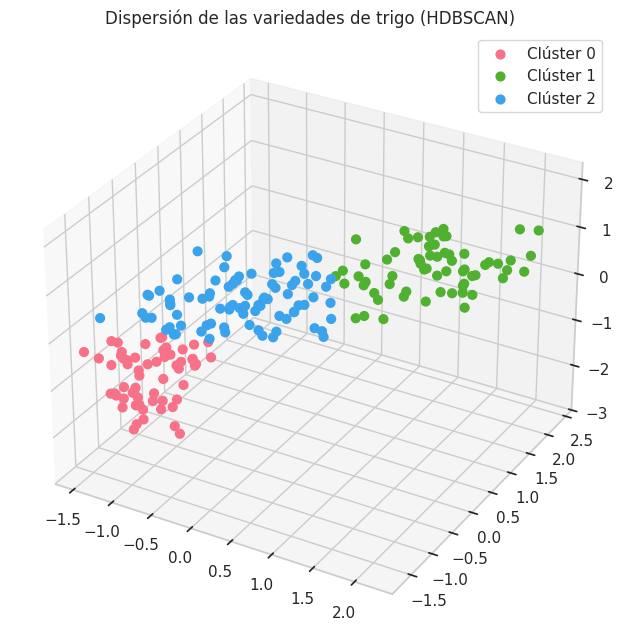

In [ ]:
# Grafico los clusters obtenidos por HDBSCAN
fig = plt.figure(figsize=(10, 6))
ax = Axes3D(fig, auto_add_to_figure=False)
fig.add_axes(ax)

# Obtengo los valores únicos de los clústeres (incluyendo el ruido, que es -1)
labels = np.unique(X_std['Cluster HDBSCAN'])

# Creo una paleta de colores
palette = sns.color_palette("husl", len(labels))

# Recorro los clústeres y asigno un color a cada uno
for label, color in zip(labels, palette):
    df1 = X_std[X_std['Cluster HDBSCAN'] == label]

    # Defino la etiqueta para el ruido
    if label == -1:
        cluster_label = 'Ruido'
    else:
        cluster_label = f'Clúster {label}'

    # Grafico los puntos para cada clúster
    ax.scatter(df1[column_names[0]], df1[column_names[1]], df1[column_names[2]],
               s=40, marker='o', color=color, alpha=1, label=cluster_label)

# Muestra la leyenda
ax.legend(loc='best')
plt.title('Dispersión de las variedades de trigo (HDBSCAN)')
plt.show()

# Validacion

##K-means

### Gap statistics

In [ ]:
def calculate_intra_cluster_dispersion(X, k):
    kmeans = KMeans(n_clusters=k) # Aplica K-means
    kmeans.fit(X_std)
    return kmeans.inertia_ # Retorna la suma de distancias al centroide

In [ ]:
gaps = []
max_k = 10

# Calcula el Gap Statistic para determinar el número óptimo de clusters

for k in range(1, max_k + 1):
    # Calculo la inercia real sobre mis datos reales
    real_inertia = calculate_intra_cluster_dispersion(X_std, k)
    #Calculo la inercia de datos aleatorios con la misma estructura que mis datos originales
    inertia_list = []
    for _ in range(10):
      random_data = np.random.rand(*X_std.shape)
      intra_cluster_dispersion = calculate_intra_cluster_dispersion(random_data, k)
      inertia_list.append(intra_cluster_dispersion)

    reference_inertia = np.mean(inertia_list)

    #Aplico la funcion de gap
    gap = np.log(reference_inertia) - np.log(real_inertia)
    gaps.append(gap)

#se selecciona el valor de k (número de clusters) que maximiza el Gap Statistic.
optimal_k = np.argmax(gaps) + 1


Número óptimo de clusters según el Gap Statistic: 8


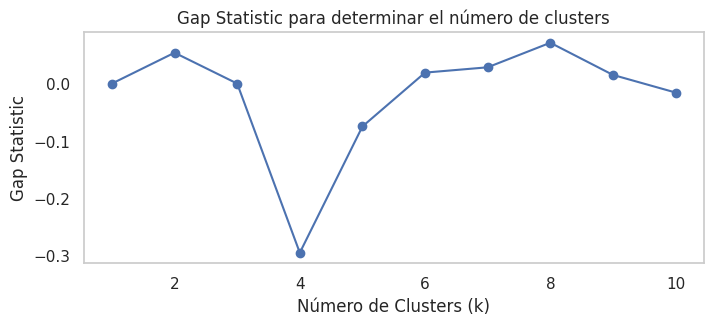

In [ ]:
print("Número óptimo de clusters según el Gap Statistic:", optimal_k)

plt.figure(figsize=(8, 3))
plt.plot(range(1, max_k + 1), gaps, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Gap Statistic')
plt.title('Gap Statistic para determinar el número de clusters')
plt.grid()
plt.show()

###Coeficiente de Silhouette

In [ ]:
def calculate_silhouette(X_scaled, k):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X_scaled)
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(X_scaled, labels)  # Calcula el coeficiente de Silhouette
    sample_silhouette_values = silhouette_samples(X_scaled, labels)
    return silhouette_avg, sample_silhouette_values

max_k = 10

silhouette_scores = []
for k in range(2, max_k + 1):
    silhouette_avg, _ = calculate_silhouette(X_std, k)
    silhouette_scores.append(silhouette_avg)

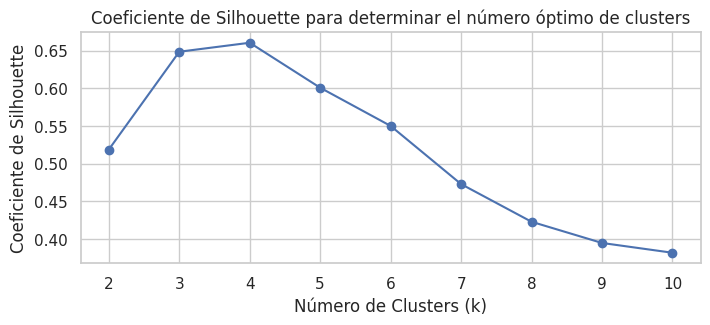

In [ ]:
plt.figure(figsize=(8, 3))
plt.plot(range(2, max_k + 1), silhouette_scores, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Coeficiente de Silhouette')
plt.title('Coeficiente de Silhouette para determinar el número óptimo de clusters')
plt.show()

## Clustering jerárquico

###Gap Statistics

In [ ]:
def calculate_intra_cluster_dispersion(X, k, linkage='ward'):
    clustering = AgglomerativeClustering(n_clusters=k, linkage=linkage)
    labels = clustering.fit_predict(X)

    # Convert X to a NumPy array for integer-based indexing
    X_np = X.to_numpy() if isinstance(X, pd.DataFrame) else X

    # Calcula los centroides de los clústeres como la media de los puntos dentro de cada clúster
    centroids = np.array([np.mean(X_np[labels == i], axis=0) for i in range(k)])

    # Calcula la dispersión intraclúster sumando las distancias al cuadrado entre los puntos y sus centroides
    # np.linalg.norm calcula la norma (distancia euclidiana) entre los puntos y el centroide correspondiente
    intra_cluster_dispersion = np.sum(np.linalg.norm(X_np[labels] - centroids[labels], axis=1)**2)
    return intra_cluster_dispersion

gaps = []
max_k = 10
for k in range(1, max_k + 1):
    # Calcula la dispersión intraclúster en los datos reales para 'k' clústeres
    X_std_numerical = X_std.select_dtypes(include=np.number)
    real_inertia = calculate_intra_cluster_dispersion(X_std_numerical, k, linkage='ward')

    inertia_list = []
    for _ in range(10):
      random_data = np.random.rand(*X_std_numerical.shape)
      intra_cluster_dispersion = calculate_intra_cluster_dispersion(random_data, k)
      inertia_list.append(intra_cluster_dispersion)

    reference_inertia = np.mean(inertia_list)

    gap = np.log(reference_inertia) - np.log(real_inertia)
    gaps.append(gap)

optimal_k = np.argmax(gaps) + 1

Número seleccionado de clusters según el Gap Statistic: 1


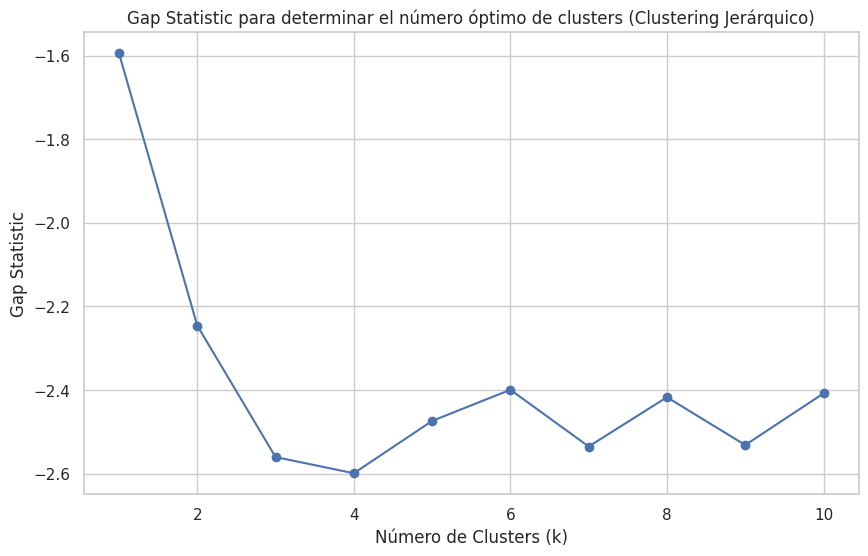

In [ ]:
print("Número seleccionado de clusters según el Gap Statistic:", optimal_k)

plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), gaps, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Gap Statistic')
plt.title('Gap Statistic para determinar el número óptimo de clusters (Clustering Jerárquico)')
plt.show()

###Coeficiente de Silhouette

In [ ]:
def calculate_silhouette(X_scaled, k, linkage='ward'):
    clustering = AgglomerativeClustering(n_clusters=k, linkage=linkage)
    labels = clustering.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, labels)
    sample_silhouette_values = silhouette_samples(X_scaled, labels)
    return silhouette_avg, sample_silhouette_values

max_k = 15

silhouette_scores = []
for k in range(2, max_k + 1):
    silhouette_avg, _ = calculate_silhouette(X_std, k)
    silhouette_scores.append(silhouette_avg)

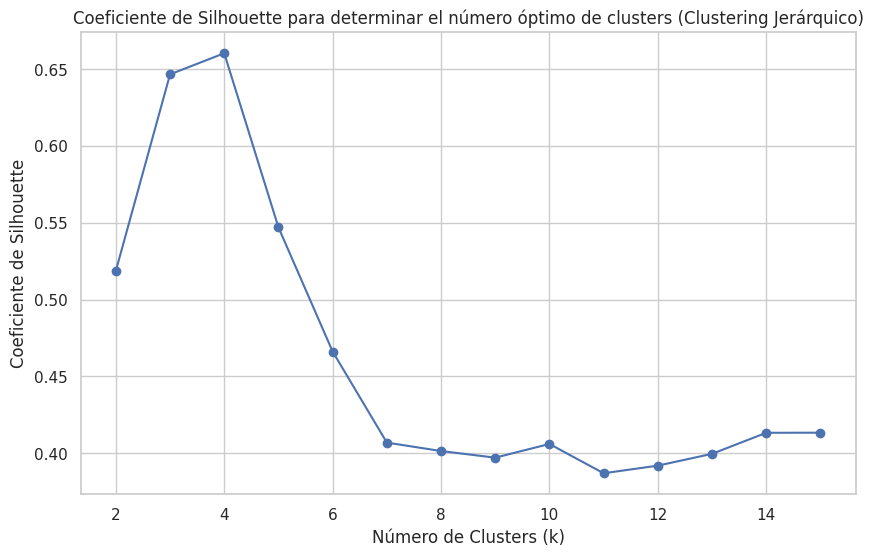

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(2, max_k + 1), silhouette_scores, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Coeficiente de Silhouette')
plt.title('Coeficiente de Silhouette para determinar el número óptimo de clusters (Clustering Jerárquico)')
plt.show()